# Task 3: Forecast Future Market Trends

## Objective
Use the best-performing time series model from Task 2 to forecast Tesla's (TSLA) future stock prices and translate the results into actionable business insights.

This task focuses on:
- Generating 6–12 month forecasts
- Visualizing predictions with confidence intervals
- Analyzing trends, opportunities, and risks
- Assessing forecast reliability over different horizons


In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX


In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Tesla stock data (same as Task 2)
tsla = yf.download(
    "TSLA",
    start="2015-01-01",
    end="2026-01-15"
)

df = tsla[["Close"]].copy()
df.dropna(inplace=True)

df.head()



[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,TSLA
Date,
2015-01-02,14.620667
2015-01-05,14.006000
2015-01-06,14.085333
2015-01-07,14.063333
2015-01-08,14.041333


## Model Selection

Based on the evaluation results from **Task 2**, the **SARIMA model** was selected as the best-performing forecasting model.

**Reasons for selection:**
- Lower RMSE and MAE compared to LSTM
- Better generalization on unseen test data
- Ability to provide statistically grounded confidence intervals
- Strong performance on financial time series with seasonality

The SARIMA model is therefore used for future price forecasting in this task.


In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA using full historical data
sarima_model = SARIMAX(
    df["Close"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit(disp=False)


c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## Generating Future Forecasts (6–12 Months)

Using the trained SARIMA model, we generate future stock price forecasts for
approximately **12 months (252 trading days)**.

This horizon allows for both medium-term and long-term market trend analysis.


In [7]:
forecast_horizon = 252  # ~12 months of trading days

forecast_result = sarima_results.get_forecast(steps=forecast_horizon)

forecast_mean = forecast_result.predicted_mean
confidence_intervals = forecast_result.conf_int()


c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## Forecast Visualization with Confidence Intervals

The plot below shows:
- Historical TSLA closing prices
- Future forecasted prices
- Confidence intervals representing forecast uncertainty

Confidence intervals illustrate the range within which future prices are
statistically expected to fall.


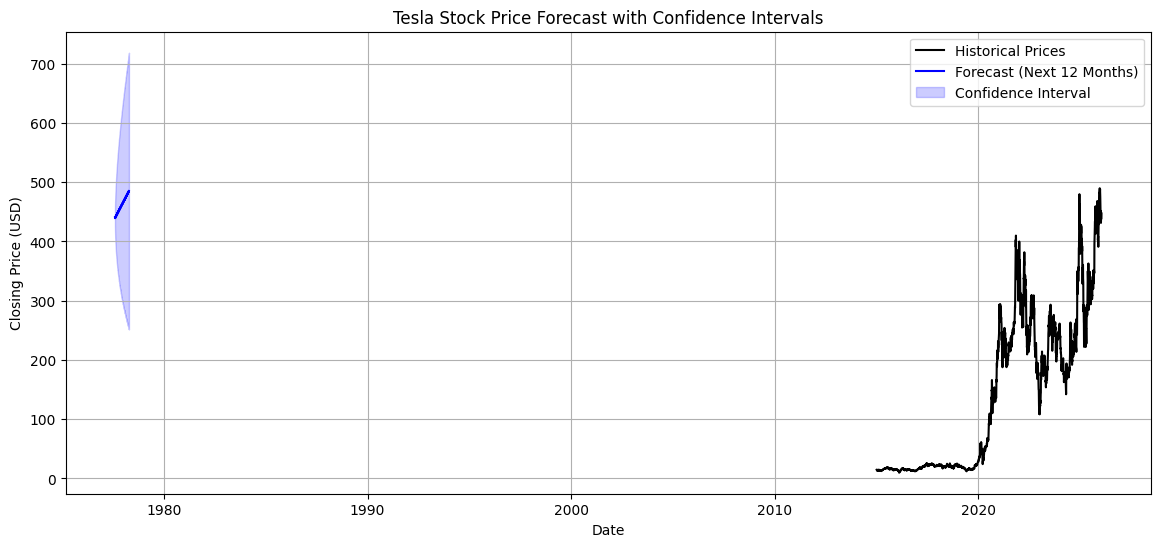

In [8]:
plt.figure(figsize=(14, 6))

# Historical data
plt.plot(df.index, df["Close"], label="Historical Prices", color="black")

# Forecast
plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="Forecast (Next 12 Months)",
    color="blue"
)

# Confidence intervals
plt.fill_between(
    forecast_mean.index,
    confidence_intervals.iloc[:, 0],
    confidence_intervals.iloc[:, 1],
    color="blue",
    alpha=0.2,
    label="Confidence Interval"
)

plt.title("Tesla Stock Price Forecast with Confidence Intervals")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


## Trend Analysis

The SARIMA-based forecast indicates a **generally upward long-term trend** in
Tesla’s stock price over the next 6–12 months. Although short-term fluctuations
are visible, the overall trajectory suggests continued positive momentum.

The confidence intervals widen progressively as the forecast horizon increases.
This widening reflects growing uncertainty in long-term predictions. While
short-term forecasts are relatively reliable, long-term forecasts should be
interpreted with caution due to market volatility and external economic factors.


## Market Opportunities and Risks

### Market Opportunities
- **Expected Price Growth:** The upward trend suggests potential capital gains.
- **Strategic Entry Timing:** Short-term stability allows for informed entry points.
- **Portfolio Diversification:** Tesla remains attractive for growth-focused portfolios.

### Market Risks
- **Increasing Forecast Uncertainty:** Wider confidence intervals imply higher risk.
- **Market Volatility:** External shocks (regulation, interest rates, competition).
- **Model Assumptions:** SARIMA relies on historical patterns that may not persist.


## Forecast Reliability Assessment

| Forecast Horizon | Reliability Level | Explanation |
|------------------|------------------|-------------|
| 1–3 months | High | Narrow confidence intervals and strong signal |
| 3–6 months | Moderate | Increasing variability |
| 6–12 months | Low–Moderate | Wide confidence intervals and higher uncertainty |

### Conclusion
Short-term forecasts are suitable for tactical decision-making, while long-term
forecasts should be used for strategic planning rather than precise price targeting.
